# FashionMNIST image classifier
**Paul Schwartzberg** | CSCI E-89 | Assignment 03, Problem 5

This notebook was built with OpenAI Codex. It trains a multilayer perceptron to recognise ten classes of clothing, records accuracy over 20 epochs and shows predictions on validation images.

The starting point is the *Building an Image Classifier with PyTorch* section of the supplied chapter 10 notebook. The training-accuracy plot is the addition required for this assignment. Prose follows the supplied *Economist Style Guide* (2015).

## 1. Load the libraries and choose a device
Run the cells in order. The Python environment needs `torch`, `torchvision`, `torchmetrics`, `matplotlib`, `pandas`, `ipykernel` and `nbconvert`. The run below records the installed versions. Device selection prefers CUDA, then MPS, then the CPU. Seeds fix the split and initial weights; results can still differ across hardware and library versions.

In [1]:
import sys
import time
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision.transforms import v2 as T
import torchmetrics
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
from IPython.display import display

%matplotlib inline
# Small matrix operations need few CPU threads.
torch.set_num_threads(2)
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}; torchvision: {torchvision.__version__}")
print(f"torchmetrics: {torchmetrics.__version__}; device: {device}")

Python: 3.12.14
PyTorch: 2.14.0+cpu; torchvision: 0.29.0+cpu
torchmetrics: 1.9.0; device: cpu


## 2. Protect the data folder and load FashionMNIST
The repository excludes `datasets/` before any download. Each greyscale image becomes a float32 tensor with values from 0 to 1. Of the 60,000 development images, 55,000 go into training and 5,000 into validation. The separate test set contains 10,000 images.

In [2]:
ignore_file = Path(".gitignore")
ignore_text = ignore_file.read_text() if ignore_file.exists() else ""
if "datasets/" not in ignore_text.splitlines():
    with ignore_file.open("a") as stream:
        stream.write(("\n" if ignore_text and not ignore_text.endswith("\n") else "") + "datasets/\n")

transform = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
full_train_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=transform)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=transform)

torch.manual_seed(42)
train_data, valid_data = random_split(full_train_data, [55_000, 5_000])
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)
class_names = full_train_data.classes

assert (len(train_data), len(valid_data), len(test_data)) == (55_000, 5_000, 10_000)
assert set(train_data.indices).isdisjoint(valid_data.indices)
x_sample, y_sample = train_data[0]
assert x_sample.shape == (1, 28, 28) and x_sample.dtype == torch.float32
assert 0 <= x_sample.min() <= x_sample.max() <= 1
print(f"Training: {len(train_data):,}; validation: {len(valid_data):,}; test: {len(test_data):,}")
print(f"Image shape: {tuple(x_sample.shape)}; dtype: {x_sample.dtype}")
print("Classes:", ", ".join(class_names))

Training: 55,000; validation: 5,000; test: 10,000
Image shape: (1, 28, 28); dtype: torch.float32
Classes: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot


## 3. Build the classifier
The network flattens each 28 by 28 image, passes it through hidden layers of 300 and 100 units, and returns ten logits. Cross-entropy uses these logits directly. Plain stochastic gradient descent uses a learning rate of 0.1.

In [3]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 300), nn.ReLU(),
    nn.Linear(300, 100), nn.ReLU(),
    nn.Linear(100, 10)
).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
assert sum(p.numel() for p in model.parameters()) == 266_610
print(model)
print("Trainable parameters: 266,610")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=300, bias=True)
  (2): ReLU()
  (3): Linear(in_features=300, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=10, bias=True)
)
Trainable parameters: 266,610


## 4. Train for 20 epochs
Training loss and accuracy cover all training batches, with predictions measured before each weight update. Validation accuracy uses the weights at the end of each epoch. Thus the two curves describe different stages of training. Each image has equal weight, including those in the last, smaller batch. The metric is reset before each pass. Validation runs without gradients; the test set stays out of training.

In [4]:
@torch.inference_mode()
def evaluate(loader):
    model.eval()
    accuracy.reset()
    correct = 0
    count = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        accuracy.update(logits, labels)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        count += labels.size(0)
    score = accuracy.compute().item()
    # Check the library metric against a direct count.
    assert abs(score - correct / count) < 1e-6
    return score

history = {"train_loss": [], "train_accuracy": [], "validation_accuracy": []}
n_epochs = 20
started = time.perf_counter()
for epoch in range(n_epochs):
    model.train()
    accuracy.reset()
    loss_sum = 0.0
    count = 0
    correct = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * labels.size(0)
        count += labels.size(0)
        accuracy.update(logits.detach(), labels)
        correct += (logits.detach().argmax(dim=1) == labels).sum().item()
    train_accuracy = accuracy.compute().item()
    assert count == 55_000 and abs(train_accuracy - correct / count) < 1e-6
    validation_accuracy = evaluate(valid_loader)
    history["train_loss"].append(loss_sum / count)
    history["train_accuracy"].append(train_accuracy)
    history["validation_accuracy"].append(validation_accuracy)
    print(f"Epoch {epoch + 1:2d}/{n_epochs}: loss {loss_sum / count:.4f}; "
          f"training {train_accuracy:.2%}; validation {validation_accuracy:.2%}")
print(f"Training time: {time.perf_counter() - started:.1f} seconds")

Epoch  1/20: loss 0.6060; training 78.13%; validation 84.16%


Epoch  2/20: loss 0.4059; training 84.94%; validation 84.22%


Epoch  3/20: loss 0.3622; training 86.67%; validation 85.92%


Epoch  4/20: loss 0.3352; training 87.67%; validation 86.38%


Epoch  5/20: loss 0.3141; training 88.42%; validation 88.04%


...

Epoch 16/20: loss 0.2092; training 91.98%; validation 88.08%


Epoch 17/20: loss 0.2033; training 92.30%; validation 88.72%


Epoch 18/20: loss 0.1996; training 92.42%; validation 88.78%


Epoch 19/20: loss 0.1934; training 92.67%; validation 87.54%


Epoch 20/20: loss 0.1866; training 92.88%; validation 88.14%
Training time: 87.3 seconds


## 5. Plot accuracy across epochs
Both curves use the recorded results from this run. The table preserves the loss and both accuracy measures for each epoch.

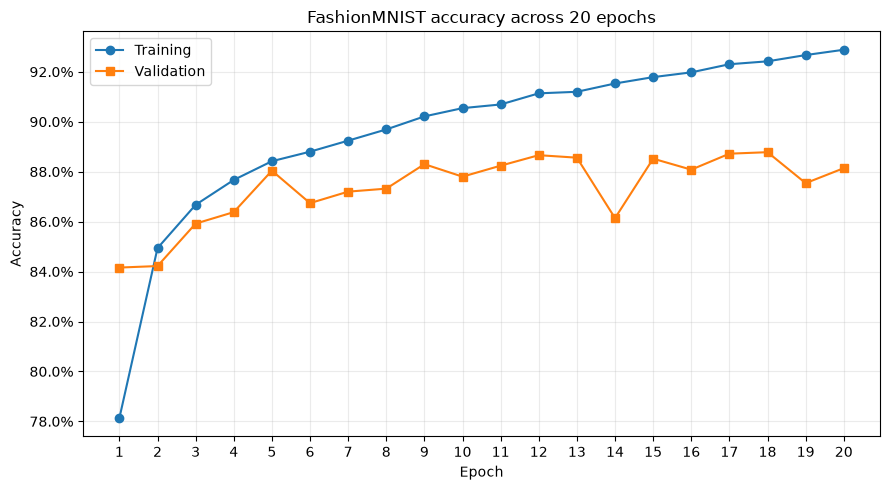

,train_loss,train_accuracy,validation_accuracy
Epoch,,,
1,0.6060,78.13%,84.16%
2,0.4059,84.94%,84.22%
3,0.3622,86.67%,85.92%
4,0.3352,87.67%,86.38%
5,0.3141,88.42%,88.04%
6,0.2987,88.80%,86.74%
7,0.2850,89.24%,87.20%
8,0.2736,89.69%,87.32%
9,0.2625,90.21%,88.30%


In [5]:
results = pd.DataFrame(history, index=pd.Index(range(1, n_epochs + 1), name="Epoch"))
assert results.shape == (20, 3) and not results.isna().any().any()
assert torch.isfinite(torch.tensor(results.values)).all()
assert (results["train_loss"] >= 0).all()
assert results[["train_accuracy", "validation_accuracy"]].apply(lambda s: s.between(0, 1).all()).all()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results.index, results.train_accuracy, "o-", label="Training")
ax.plot(results.index, results.validation_accuracy, "s-", label="Validation")
ax.set(title="FashionMNIST accuracy across 20 epochs", xlabel="Epoch", ylabel="Accuracy")
ax.set_xticks(range(1, 21))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()
display(results.style.format({"train_loss": "{:.4f}", "train_accuracy": "{:.2%}", "validation_accuracy": "{:.2%}"}))

## 6. Check the held-out test set
Evaluate the final model once on the test set. No test result is used to choose weights or settings. The reported training accuracy remains the accuracy measured during the final training epoch.

In [6]:
test_accuracy = evaluate(test_loader)
print(f"Final training accuracy: {history['train_accuracy'][-1]:.4%}")
print(f"Final validation accuracy: {history['validation_accuracy'][-1]:.4%}")
print(f"Held-out test accuracy: {test_accuracy:.4%}")

Final training accuracy: 92.8818%
Final validation accuracy: 88.1400%
Held-out test accuracy: 87.7200%


## 7. Inspect validation predictions
Use the first six validation images in their fixed order. Titles compare predicted and true class names. The first table gives all ten softmax probabilities; the second lists the four most likely classes for each image. The top four retain their probabilities from the full distribution. Softmax scores express the model's estimates; they do not establish how well calibrated those estimates are.

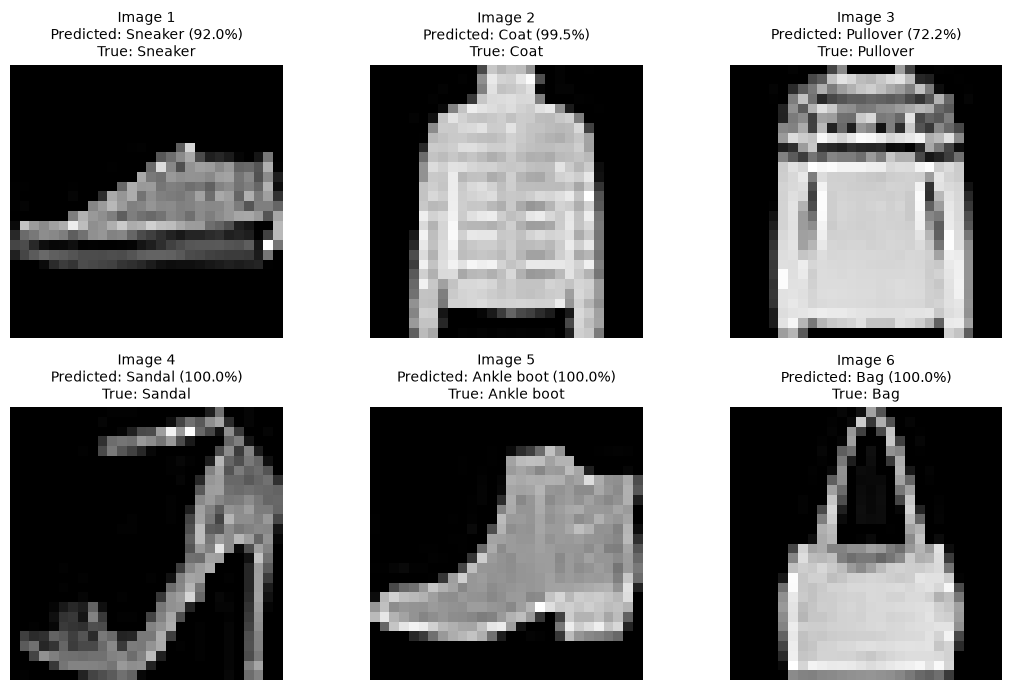

,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
Image,,,,,,,,,,
1,0.00%,0.00%,0.00%,0.00%,0.00%,0.04%,0.00%,92.02%,0.01%,7.93%
2,0.00%,0.00%,0.50%,0.00%,99.48%,0.00%,0.02%,0.00%,0.00%,0.00%
3,0.11%,0.02%,72.19%,0.08%,15.50%,0.00%,11.97%,0.00%,0.12%,0.00%
4,0.00%,0.00%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0.00%
5,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,100.00%
6,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,100.00%,0.00%


Image,True class,Rank,Predicted class,Probability
1,Sneaker,1,Sneaker,92.02%
1,Sneaker,2,Ankle boot,7.93%
1,Sneaker,3,Sandal,0.04%
1,Sneaker,4,Bag,0.01%
2,Coat,1,Coat,99.48%
2,Coat,2,Pullover,0.50%
2,Coat,3,Shirt,0.02%
2,Coat,4,Bag,0.00%
3,Pullover,1,Pullover,72.19%
3,Pullover,2,Coat,15.50%


Checks passed: data split, image format, parameter count, accuracy counts, history and probabilities.


In [7]:
images, labels = next(iter(valid_loader))
images, labels = images[:6], labels[:6]
model.eval()
with torch.inference_mode():
    probabilities = model(images.to(device)).softmax(dim=1).cpu()
predictions = probabilities.argmax(dim=1)
top_probabilities, top_classes = probabilities.topk(4, dim=1)
assert probabilities.shape == (6, 10)
assert torch.allclose(probabilities.sum(dim=1), torch.ones(6), atol=1e-6)
assert torch.equal(top_classes[:, 0], predictions)

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for i, ax in enumerate(axes.flat):
    predicted, actual = class_names[predictions[i].item()], class_names[labels[i].item()]
    ax.imshow(images[i, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Image {i + 1}\nPredicted: {predicted} ({probabilities[i].max():.1%})\nTrue: {actual}", fontsize=10)
    ax.axis("off")
fig.tight_layout()
plt.show()
probability_table = pd.DataFrame(probabilities.numpy(), columns=class_names,
                                 index=pd.Index(range(1, 7), name="Image"))
display(probability_table.style.format("{:.2%}"))
rows = []
for i in range(6):
    for rank in range(4):
        rows.append({"Image": i + 1, "True class": class_names[labels[i].item()],
                     "Rank": rank + 1, "Predicted class": class_names[top_classes[i, rank].item()],
                     "Probability": top_probabilities[i, rank].item()})
display(pd.DataFrame(rows).style.hide(axis="index").format({"Probability": "{:.2%}"}))
print("Checks passed: data split, image format, parameter count, accuracy counts, history and probabilities.")

## 8. Sources and export
The supplied `10_neural_nets_with_pytorch.ipynb`, chapter 10 of Aurelien Geron's *Hands-On Machine Learning with Scikit-Learn and PyTorch* (2025), provides the model and data-loading pattern. The supplied Assignment 03 defines Problem 5. The requested settings determine this run; there is no hyperparameter search.

After running all cells, save the notebook and export its saved outputs from a terminal:

```sh
jupyter nbconvert --to html e89_Schwartzberg_Paul_HW03_Prob5.ipynb
```